In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages #reducer function to append messages instead of replacing old messages

In [2]:
class ChatState(TypedDict):
    messages: Annotated[BaseMessage,add_messages ] # such that messages can be classified as human message, system message, AI message
    #if we dont use basemessage then the field value will be simple string, or other datatype and BaseMessage is base class of all three message types
    # annotated and add messages appends new message whereas normal fields replaces old value

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()
GROQ_MODEL = "llama-3.3-70b-versatile"
groq_api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model=GROQ_MODEL)

In [ ]:
def chat_node(state: ChatState):
    messages = state['messages'] 
    # in above step if state['messages'] already has 1000k messages then messages holds all those messages and llm.invoke reads all those
    #but acceptance of llm depends on context window size, but sending every message isnt suitable so we use a. Trim (messages = state["messages"][-20:]) b. Summarize old history and send that message 
    response = llm.invoke(messages)
    return {'messages':[response]} #because messages is a list

In [5]:
graph = StateGraph(ChatState) #state (basically model that holds data)

graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node"),
graph.add_edge("chat_node",END)

In [6]:
chatbot = graph.compile()

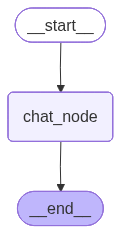

In [7]:
chatbot

In [8]:
initial_state = {
    'messages':[HumanMessage(content="What is the capital of India")]
}
chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='What is the capital of India', additional_kwargs={}, response_metadata={}, id='2201e389-5729-4445-988e-d07564c0150e'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 41, 'total_tokens': 50, 'completion_time': 0.011841169, 'completion_tokens_details': None, 'prompt_time': 0.002434762, 'prompt_tokens_details': None, 'queue_time': 0.162246318, 'total_time': 0.014275931}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--f8b2590b-8937-413e-960e-23134b695af3-0', usage_metadata={'input_tokens': 41, 'output_tokens': 9, 'total_tokens': 50})]}

In [9]:
chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is New Delhi.'

In [10]:
while True:
    user_message = input('Type here: ')
    print(f"User: {user_message.strip()}")
    if user_message.strip().lower() in ['exit', 'break', 'quit']:
        break
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]})
    print(f"AI answers as: {response['messages'][-1].content}")

# User: My name is A
# AI answers as: Hello A, it's nice to meet you. Is there something I can help you with or would you like to chat?
# User: What is my name?
# AI answers as: I don't know your name. I'm a large language model, I don't have the ability to know your personal information, including your name, unless you tell me. If you'd like to share your name, I'd be happy to chat with you and use it in our conversation.
# User: exit

User: Hi
AI answers as: It's nice to meet you. Is there something I can help you with, or would you like to chat?
User: My name is A
AI answers as: Hello A, it's nice to meet you. Is there something I can help you with or would you like to chat?
User: What is my name
AI answers as: I don't know your name. I'm a large language model, I don't have the ability to know your personal information, including your name, unless you tell me. If you'd like to share your name, I'd be happy to chat with you and address you by your name.
User: exit


In [11]:
from langgraph.checkpoint.memory import MemorySaver #stores data in RAM
checkpointer = MemorySaver()

In [12]:
chatbot_with_checkpointer = graph.compile(checkpointer=checkpointer) #it remembers conversation 
# User: My name is A
# AI answers as: Nice to meet you, A. It's great that you're willing to share a bit about yourself. If you're comfortable, I can call you A from now on. How's your day going so far?
# User: What is my name?
# AI answers as: You told me your name is A.


In [13]:
#thread_id with checkpointer (thread is each set of interaction with the chatbot, again a user can select a new thread for any new conversation)
thread_id = '1'
while True:
    user_message = input('Type here: ')
    print(f"User: {user_message.strip()}")
    if user_message.strip().lower() in ['exit', 'break', 'quit']:
        break
    #when interacting with chatbot we create a config
    config = {'configurable': {'thread_id':thread_id}}
    response = chatbot_with_checkpointer.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print(f"AI answers as: {response['messages'][-1].content}")


User: Hi
AI answers as: It's nice to meet you. Is there something I can help you with or would you like to chat?
User: Mu name is A
AI answers as: Nice to meet you, A. It's lovely to have you here. Is there something on your mind that you'd like to talk about, or would you like some recommendations on topics we could discuss?
User: What is my name?
AI answers as: You told me your name is A.
User: exit


In [14]:
chatbot_with_checkpointer.get_state(config=config) #each thread refers to each user interaction hence we need to send config

StateSnapshot(values={'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='6211eea3-a1b4-437a-b4f3-a0666c079f89'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.06293086, 'completion_tokens_details': None, 'prompt_time': 0.002222711, 'prompt_tokens_details': None, 'queue_time': 0.048451206, 'total_time': 0.065153571}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--e0dbc42c-609f-441c-8927-aa7fa3abbdf1-0', usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59}), HumanMessage(content='Mu name is A', additional_kwargs={}, response_metadata={}, id='8e537940-8a5c-479d-80a1-1f44c6ef8278'), AIMessage(content="Nice to mee

In [15]:
#with system message
from langchain_core.messages import SystemMessage
response = chatbot_with_checkpointer.invoke(
        {
            "messages": [
                SystemMessage(
                    content="You are a helpful AI assistant that explains concepts simply."
                ),
                HumanMessage(content=user_message)
            ]
        },
        config=config
)

# Persistence

In [ ]:
class JokeState(TypedDict): #What is state in langgraph? is the shape of data flowing between nodes.
    topic: str
    joke: str
    explanation: str

In [17]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [ ]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}' #in previous step we have field called 'joke' state['any fields we generate using annotated, basemodel, typeddict']
    response = llm.invoke(prompt).content
    #to force llm to give structured output we use structured_llm = llm.with_structured_output(JokeResponse)

    return {'explanation': response}

In [19]:
from langgraph.checkpoint.memory import InMemorySaver

graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [ ]:
config1 = {"configurable": {"thread_id": "1"}}
initial_state = {
    'topic':'pizza'
}
workflow.invoke(initial_state, config=config1) #Is initial state compulsory? Yes, When starting a graph, you must provide enough state for the first node.


{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'This joke is a play on words, using a pun to create humor. The phrase "feeling a little crusty" has a double meaning here. \n\nIn one sense, "crusty" can describe someone who is irritable, gruff, or in a bad mood. For example, you might say "He\'s been feeling crusty all day" to mean that someone is being grumpy or short-tempered.\n\nHowever, in the context of the joke, "crusty" also refers to the crust of a pizza, which is the outer layer of the bread. So, the joke is making a clever connection between the pizza\'s physical crust and the idea of being in a bad mood (feeling crusty). The punchline relies on this wordplay to create a humorous effect, as it\'s an unexpected and clever twist on the usual meaning of the phrase.'}

In [21]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a pun to create humor. The phrase "feeling a little crusty" has a double meaning here. \n\nIn one sense, "crusty" can describe someone who is irritable, gruff, or in a bad mood. For example, you might say "He\'s been feeling crusty all day" to mean that someone is being grumpy or short-tempered.\n\nHowever, in the context of the joke, "crusty" also refers to the crust of a pizza, which is the outer layer of the bread. So, the joke is making a clever connection between the pizza\'s physical crust and the idea of being in a bad mood (feeling crusty). The punchline relies on this wordplay to create a humorous effect, as it\'s an unexpected and clever twist on the usual meaning of the phrase.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1657c6-a9d4-6777-8002-dcab6

In [22]:
list(workflow.get_state_history(config1)) #why 4? Because we have 4 nodes start -> joke -> explain -> answer 

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a pun to create humor. The phrase "feeling a little crusty" has a double meaning here. \n\nIn one sense, "crusty" can describe someone who is irritable, gruff, or in a bad mood. For example, you might say "He\'s been feeling crusty all day" to mean that someone is being grumpy or short-tempered.\n\nHowever, in the context of the joke, "crusty" also refers to the crust of a pizza, which is the outer layer of the bread. So, the joke is making a clever connection between the pizza\'s physical crust and the idea of being in a bad mood (feeling crusty). The punchline relies on this wordplay to create a humorous effect, as it\'s an unexpected and clever twist on the usual meaning of the phrase.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1657c6-a9d4-6777-8002-dcab

In [23]:
#'1f165593-882e-6f31-bfff-57501a483315 before start checkpoint id hence values are empty
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f165593-882e-6f31-bfff-57501a483315"}})


StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f165593-882e-6f31-bfff-57501a483315'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [24]:

config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a lifelong commitment.',
 'explanation': 'This joke is a play on words, using the physical properties of spaghetti to create a humorous connection with the concept of marriage and commitment.\n\nThe punchline "it was afraid of getting tangled up in a lifelong commitment" has a double meaning. On one hand, spaghetti is a type of long, thin, and flexible pasta that can easily become tangled or knotted. So, in a literal sense, the spaghetti might be afraid of getting physically tangled up.\n\nOn the other hand, the phrase "tangled up in a lifelong commitment" is a common idiomatic expression used to describe the complexities and responsibilities that come with a long-term relationship or marriage. It implies a sense of being deeply involved or entwined with someone, to the point where it can be difficult to separate or extricate oneself.\n\nThe joke relies on this wo

In [25]:
list(workflow.get_state_history(config1)) #why 4? Because we have 4 nodes start -> joke -> explain -> answer 

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a pun to create humor. The phrase "feeling a little crusty" has a double meaning here. \n\nIn one sense, "crusty" can describe someone who is irritable, gruff, or in a bad mood. For example, you might say "He\'s been feeling crusty all day" to mean that someone is being grumpy or short-tempered.\n\nHowever, in the context of the joke, "crusty" also refers to the crust of a pizza, which is the outer layer of the bread. So, the joke is making a clever connection between the pizza\'s physical crust and the idea of being in a bad mood (feeling crusty). The punchline relies on this wordplay to create a humorous effect, as it\'s an unexpected and clever twist on the usual meaning of the phrase.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1657c6-a9d4-6777-8002-dcab

In [26]:
#Updating State at which node you update the state there a checkpoint would be created and then again resumes
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f165593-8831-69d3-8000-3a7b94577321", "checkpoint_ns": ""}}, {'topic':'samosa'})


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1657c6-bc0d-6b01-8000-3e87b741e65a'}}

In [27]:
list(workflow.get_state_history(config1))


[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1657c6-bc0d-6b01-8000-3e87b741e65a'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-06-11T10:00:48.334704+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f165593-8831-69d3-8000-3a7b94577321'}}, tasks=(PregelTask(id='6b21001c-df8e-d90d-e4b7-f79df408f9ae', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a pun to create humor. The phrase "feeling a little crusty" has a double meaning here. \n\nIn one sense, "crusty" can describe someone who is irritable, gruff, or in a bad mood. For example, you might

In [28]:
#after updating checkpoint now we need to call or resume the graph to get generate joke method
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1655a2-8a46-6c96-8001-632c09812ac0"}})


EmptyInputError: Received no input for __start__

# Fault tolerance

In [29]:

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [30]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [31]:
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang when you see above print statement stop the code cell and start again then it re-runs from stopped point
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [32]:
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:

try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


: 

In [ ]:
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)



🔁 Re-running the graph to demonstrate fault tolerance...


NameError: name 'graph' is not defined

: 

# Tools

In [33]:
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
import requests


@tool
def web_search(query: str) -> str:
    """Searches the live web for recent, real-time, or historical information using DuckDuckGo. 
    Use this whenever you need to find facts or check information.
    """
    search = DuckDuckGoSearchRun()
    return search.invoke(query)


@tool
def calculator(a: float, b:float, operation:str) -> dict:
    """Performs basic arithmethic operation on two numbers
    """
    try:
        if operation == 'add':
            result = a+b
        elif operation == 'sub':
            result = a-b
        elif operation == 'mul':
            result = a * b
        else:
            return {"error":f"Unsupported operation: {operation}"}
        
        return {"a":a, "b":b, "operation":operation, "answer": result}

    except Exception as e:
        return {"error": str(e)}

   

In [34]:
tools = [web_search, calculator]
llm_with_tools = llm.bind_tools(tools)


In [46]:
def chat_tool_node(state:ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

In [47]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_tool_node)
graph.add_node("tools", tool_node)

In [48]:
graph.add_edge(START, "chat_node")

#if llm asked for a tool, go to toolnode else finish
graph.add_conditional_edges("chat_node", tools_condition)

In [49]:
chatbot = graph.compile()

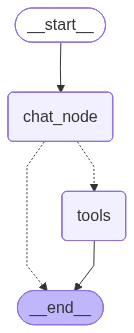

In [50]:
chatbot

In [51]:
initial_state = {
    'messages': [HumanMessage(content="What is the sum of 1000 and 23456789")]
}
out = chatbot.invoke(initial_state)
out

{'messages': [HumanMessage(content='What is the sum of 1000 and 23456789', additional_kwargs={}, response_metadata={}, id='21e2c633-8711-4ae8-a3be-ee1aad19d503'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4jsj0fpf7', 'function': {'arguments': '{"a":1000,"b":23456789,"operation":"addition"}', 'name': 'calculator'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 353, 'total_tokens': 383, 'completion_time': 0.079100122, 'completion_tokens_details': None, 'prompt_time': 0.019102425, 'prompt_tokens_details': None, 'queue_time': 0.211423472, 'total_time': 0.098202547}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--9601db66-3d69-40b1-8e9b-e476f5a0d3a7-0', tool_calls=[{'name': 'calculator', 'args': {'a': 1000, 'b': 23456789, 'operation': 'addition'}, 'id': '4jsj0fpf7', 'type': 'tool_call'}], usage_

The model sees "arithmetic operation" and naturally thinks:
addition
subtraction
multiplication
SO edit the tool description to 
    """
    Performs arithmetic.

    operation must be one of:
    - add
    - sub
    - mul
    """

from typing import Literal

@tool
def calculator(
    a: float,
    b: float,
    operation: Literal["add", "sub", "mul"]
):
    """Perform arithmetic."""